# Compute multi-hospital access

Compute network distance from each grid cell to multiple nearby hospitals, then derive a multi-hospital accessibility score using distance decay.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    FILES,
    TOP_K_HOSPITALS,
    DISTANCE_DECAY_ALPHA,
    EPSILON,
    ensure_project_dirs,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Nairobi
BBOX: {'lon_min': 36.6, 'lat_min': -1.5, 'lon_max': 37.1, 'lat_max': -1.1}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/hrsl_kenya.tif


In [2]:
nearest_access = gpd.read_parquet(FILES["nearest_access"])
hospitals = gpd.read_parquet(FILES["hospitals"])
roads = ox.load_graphml(FILES["roads_graphml"])

print("Grid cells:", len(nearest_access))
print("Hospitals:", len(hospitals))
print("Road nodes:", len(roads.nodes))
print("Road edges:", len(roads.edges))

Grid cells: 2520
Hospitals: 326
Road nodes: 86640
Road edges: 212368


In [3]:
roads = ox.project_graph(roads)
nodes_gdf, _ = ox.graph_to_gdfs(roads)
graph_crs = nodes_gdf.crs

print("Projected graph CRS:", graph_crs)

Projected graph CRS: EPSG:32737


In [4]:
nearest_access = nearest_access.to_crs(graph_crs)
hospitals = hospitals.to_crs(graph_crs)

nearest_access["centroid"] = nearest_access.geometry.centroid

grid_centroids = gpd.GeoDataFrame(
    nearest_access[["grid_id", "population", "population_density_km2"]].copy(),
    geometry=nearest_access["centroid"],
    crs=graph_crs,
)

print("Grid centroid CRS:", grid_centroids.crs)
print("Hospital CRS:", hospitals.crs)

Grid centroid CRS: EPSG:32737
Hospital CRS: EPSG:32737


In [5]:
grid_centroids["nearest_node"] = ox.distance.nearest_nodes(
    roads,
    X=grid_centroids.geometry.x.to_numpy(),
    Y=grid_centroids.geometry.y.to_numpy()
)

hospitals["nearest_node"] = ox.distance.nearest_nodes(
    roads,
    X=hospitals.geometry.x.to_numpy(),
    Y=hospitals.geometry.y.to_numpy()
)

print("Unique hospital nodes:", hospitals["nearest_node"].nunique())

Unique hospital nodes: 280


In [6]:
hospital_nodes_df = (
    hospitals[["nearest_node", "name", "geometry"]]
    .drop_duplicates(subset=["nearest_node"])
    .reset_index(drop=True)
    .copy()
)

hospital_nodes_df["hospital_id"] = [f"h_{i:04d}" for i in range(len(hospital_nodes_df))]

hospital_nodes_df.head()

,nearest_node,name,geometry,hospital_id
0,7730852179,M. P. Shah Hospital,POINT (256526.166 9860212.125),h_0000
1,8502595693,Upendo Vision Clinic,POINT (253644.928 9855332.315),h_0001
2,6165841039,St Augustus Medical Clinic,POINT (253953.539 9855403.169),h_0002
3,293323426,Wema Clinic,POINT (252775.728 9854218.877),h_0003
4,7723878225,Saola Health Clinic,POINT (255098.45 9854907.723),h_0004


In [7]:
hospital_node_to_id = dict(
    zip(hospital_nodes_df["nearest_node"], hospital_nodes_df["hospital_id"])
)

hospital_node_list = hospital_nodes_df["nearest_node"].tolist()

print("Hospital node count used for analysis:", len(hospital_node_list))

Hospital node count used for analysis: 280


In [8]:
multi_access_rows = []

for idx, row in grid_centroids.iterrows():
    source_node = row["nearest_node"]

    lengths = nx.single_source_dijkstra_path_length(
        roads,
        source=source_node,
        weight="length"
    )

    hospital_distances = []
    for hospital_node in hospital_node_list:
        if hospital_node in lengths:
            hospital_distances.append(
                (hospital_node_to_id[hospital_node], hospital_node, lengths[hospital_node])
            )

    hospital_distances = sorted(hospital_distances, key=lambda x: x[2])[:TOP_K_HOSPITALS]

    for rank, (hospital_id, hospital_node, distance_m) in enumerate(hospital_distances, start=1):
        multi_access_rows.append({
            "grid_id": row["grid_id"],
            "hospital_id": hospital_id,
            "hospital_node": hospital_node,
            "rank": rank,
            "distance_m": float(distance_m)
        })

    if idx % 250 == 0:
        print(f"Processed {idx} / {len(grid_centroids)} grid cells")

Processed 0 / 2520 grid cells
Processed 250 / 2520 grid cells
Processed 500 / 2520 grid cells
Processed 750 / 2520 grid cells
Processed 1000 / 2520 grid cells
Processed 1250 / 2520 grid cells
Processed 1500 / 2520 grid cells
Processed 1750 / 2520 grid cells
Processed 2000 / 2520 grid cells
Processed 2250 / 2520 grid cells
Processed 2500 / 2520 grid cells


In [9]:
multi_access_long = pd.DataFrame(multi_access_rows)

print("Rows in long access table:", len(multi_access_long))
multi_access_long.head()

Rows in long access table: 7560


,grid_id,hospital_id,hospital_node,rank,distance_m
0,g_00000,h_0252,2482452771,1,18919.701825
1,g_00000,h_0160,6330960585,2,24042.362610
2,g_00000,h_0253,703562780,3,30367.019545
3,g_00001,h_0252,2482452771,1,19302.596780
4,g_00001,h_0160,6330960585,2,24425.257564


In [13]:
DISTANCE_FLOOR_M = 500.0

multi_access_long["distance_decay"] = 1.0 / (
    (multi_access_long["distance_m"] + DISTANCE_FLOOR_M) ** DISTANCE_DECAY_ALPHA
)

multi_access_score = (
    multi_access_long.groupby("grid_id", as_index=False)["distance_decay"]
    .sum()
    .rename(columns={"distance_decay": "multi_access_score"})
)

print(multi_access_score["multi_access_score"].describe())
multi_access_score.head()

count    2.520000e+03
mean     1.036607e-05
std      1.789872e-05
min      6.066395e-07
25%      2.039728e-06
50%      4.309219e-06
75%      1.100176e-05
max      2.281744e-04
Name: multi_access_score, dtype: float64


,grid_id,multi_access_score
0,g_00000,8.140083e-07
1,g_00001,7.939942e-07
2,g_00002,7.939942e-07
3,g_00003,7.207551e-07
4,g_00004,7.750054e-07


In [14]:
multi_access = nearest_access.merge(
    multi_access_score,
    on="grid_id",
    how="left"
)

multi_access["multi_access_score"] = multi_access["multi_access_score"].fillna(0)

print("Missing multi-access scores:", multi_access["multi_access_score"].isna().sum())
multi_access[["grid_id", "nearest_hospital_distance_m", "multi_access_score"]].head()

Missing multi-access scores: 0


,grid_id,nearest_hospital_distance_m,multi_access_score
0,g_00000,18919.701825,8.140083e-07
1,g_00001,19302.596780,7.939942e-07
2,g_00002,19302.596780,7.939942e-07
3,g_00003,21495.756410,7.207551e-07
4,g_00004,20307.217036,7.750054e-07


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/06_multi_hospital_access_score_clipped.png


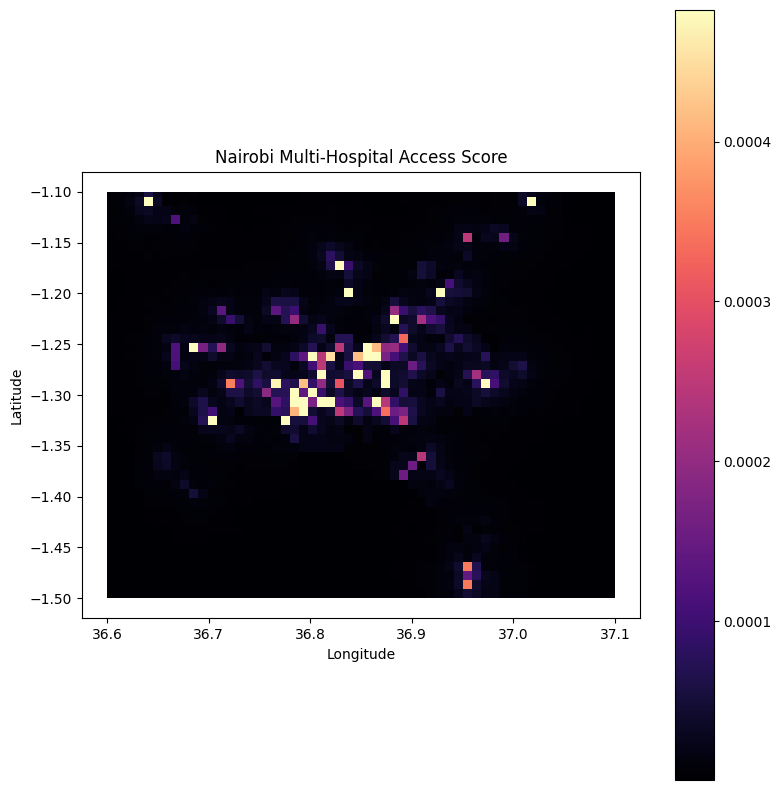

In [17]:
vmax = multi_access_wgs84["multi_access_score"].quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 8))

multi_access_wgs84.plot(
    column="multi_access_score",
    ax=ax,
    cmap="magma",
    legend=True,
    linewidth=0,
    vmax=vmax
)

ax.set_title(f"{CITY_NAME} Multi-Hospital Access Score")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "06_multi_hospital_access_score_clipped.png")
plt.show()

In [20]:
multi_access.to_parquet(FILES["multi_access"], index=False)
print("Saved multi-access grid to:", FILES["multi_access"])

Saved multi-access grid to: /Users/suvo/Projects/urban-healthcare/data/processed/multi_hospital_access.parquet


In [22]:
multi_access_long_path = Path(FILES["multi_access"]).parent / "multi_access_long.parquet"

multi_access_long.to_parquet(multi_access_long_path, index=False)

print("Saved long multi-access table to:", multi_access_long_path)

Saved long multi-access table to: /Users/suvo/Projects/urban-healthcare/data/processed/multi_access_long.parquet
